In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from influxdb_client import InfluxDBClient
import os
from dotenv import load_dotenv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from influxdb_client import InfluxDBClient
import os
from dotenv import load_dotenv
from influxdb_client import InfluxDBClient

load_dotenv()

INFLUX_URL = os.getenv("INFLUX_URL", "http://localhost:8086")
INFLUX_TOKEN = os.getenv("INFLUX_TOKEN")
INFLUX_ORG = os.getenv("INFLUX_ORG", "casa")
INFLUX_BUCKET = os.getenv("INFLUX_BUCKET", "monitoraggio_pi")


if not INFLUX_TOKEN:
    print("Errore: INFLUX_TOKEN non trovato! WTF .env.")
else:
    print(f" Configurazione caricata correttamente!")
    print(f" URL: {INFLUX_URL} |  Bucket: {INFLUX_BUCKET}")
    
# Inizializza il client
client = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG)
query_api = client.query_api()

# query Flux (prendiamo l'ultima ora di dati)
query = f'''
from(bucket: "{INFLUX_BUCKET}")
  |> range(start: -3h)
  |> filter(fn: (r) => r["_measurement"] == "ambiente")
'''

df = query_api.query_data_frame(query)
client.close()

df.head()


 Configurazione caricata correttamente!
 URL: http://10.26.169.209:8086 |  Bucket: monitoraggio_pi


/home/linkyolo/anaconda3/lib/python3.13/site-packages/influxdb_client/client/warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
from(bucket: "monitoraggio_pi")
  |> range(start: -3h)
  |> filter(fn: (r) => r["_measurement"] == "ambiente")
 |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")

You can disable this warning by:
    import warnings
    from influxdb_client.client.warnings import MissingPivotFunction

    warnings.simplefilter("ignore", MissingPivotFunction)

For more info see:
    - https://docs.influxdata.com/resources/videos/pivots-in-flux/
    - https://docs.influxdata.com/flux/latest/stdlib/universe/pivot/
    - https://docs.influxdata.com/flux/latest/stdlib/influxdata/influxdb/schema/fieldsascols/

  warnings.warn(message, MissingPivotFunction)


,result,table,_start,_stop,_time,_value,_field,_measurement,host,stanza
0,_result,0,2026-07-11 08:21:08.604380+00:00,2026-07-11 11:21:08.604380+00:00,2026-07-11 09:30:39.657029+00:00,34.0,percepita,ambiente,raspberry_pi_4,camera
1,_result,0,2026-07-11 08:21:08.604380+00:00,2026-07-11 11:21:08.604380+00:00,2026-07-11 09:30:50.235020+00:00,34.0,percepita,ambiente,raspberry_pi_4,camera
2,_result,0,2026-07-11 08:21:08.604380+00:00,2026-07-11 11:21:08.604380+00:00,2026-07-11 09:30:55.508314+00:00,34.0,percepita,ambiente,raspberry_pi_4,camera
3,_result,0,2026-07-11 08:21:08.604380+00:00,2026-07-11 11:21:08.604380+00:00,2026-07-11 09:31:00.782786+00:00,34.0,percepita,ambiente,raspberry_pi_4,camera
4,_result,0,2026-07-11 08:21:08.604380+00:00,2026-07-11 11:21:08.604380+00:00,2026-07-11 09:31:06.044304+00:00,34.3,percepita,ambiente,raspberry_pi_4,camera


In [2]:
df.to_csv("data/days/11-luglio-2026.csv")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from influxdb_client import InfluxDBClient
import os
from dotenv import load_dotenv
from influxdb_client import InfluxDBClient
df = pd.read_csv( "data/days/11-luglio-2026.csv")

In [3]:

class Evento:
    def __init__(self, description, time, color='b'):

        self.description = description
        self.time = time
        self.color = color 

allEvents = [
    
    Evento('corr verso stanza', pd.to_datetime("2026-07-11 09:41:39.657029+00:00"), 'g'),
    Evento('verso balcone', pd.to_datetime("2026-07-11 10:10:39.657029+00:00"), 'r'),
    Evento('corr verso stanza', pd.to_datetime("2026-07-11 10:24:39.657029+00:00"), 'g'),
    Evento('Fan on, F room, pointed outside', pd.to_datetime("2026-07-11 10:41:39.657029+00:00"), 'purple'),
    Evento('Fan on, F room, pointed inside', pd.to_datetime("2026-07-11 10:45:39.657029+00:00"), 'purple'),
    Evento('Fan on, F room, pointed corr', pd.to_datetime("2026-07-11 10:51:39.657029+00:00"), 'purple'),

] 

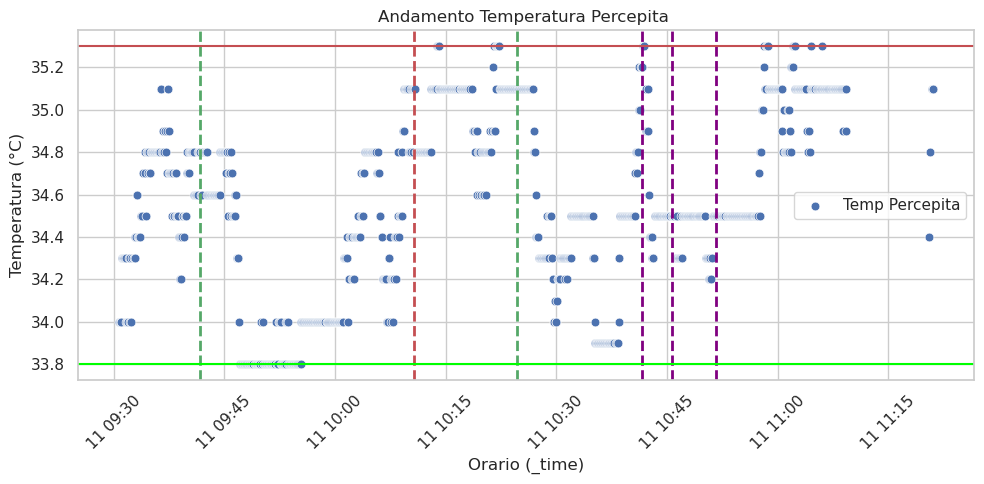

In [4]:
import seaborn as sns

df_loaded = df
df_loaded['_time'] = pd.to_datetime(df_loaded['_time'])
df_target = df_loaded[df_loaded['_field'] == 'percepita'].copy()

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.scatterplot(data=df_target, x='_time', y='_value',  color='b', s=40, label='Temp Percepita')

for event in allEvents:
    plt.axvline(x=event.time, color=event.color, linestyle='--', linewidth=2, label=event.description)

#minimo
plt.axhline(df_target['_value'][1:].min(), color='lime')
plt.axhline(df_target['_value'][1:].max(), color='r')
plt.title('Andamento Temperatura Percepita ')
plt.xlabel('Orario (_time)')
plt.ylabel('Temperatura (°C)')
plt.xticks(rotation=45)
#plt.legend()
plt.tight_layout()

plt.show()
#plt.savefig('temp_plot.png')

plt.close()


In [9]:
eventoDelimitatore =  allEvents[1]
indexEventoPicked = allEvents.index(eventoDelimitatore)
print(f'index:  {indexEventoPicked}')
df_target['periodo'] = np.where(df_target['_time'] < eventoDelimitatore.time , 'Prima', 'Dopo')

# 1. Reset index 
df_prima = df_target[df_target['periodo'] == 'Prima'].copy().reset_index(drop=True)
df_dopo = df_target[df_target['periodo'] == 'Dopo'].copy().reset_index(drop=True)

print("Head of df_prima (with reset index):")
print(df_prima[['_time', '_value']].head(3))
print("\nHead of df_dopo (with reset index):")
print(df_dopo[['_time', '_value']].head(3))

# 2. Compare aggregated metrics
confronto = df_target.groupby('periodo')['_value'].agg(['mean', 'min', 'max', 'std']).reset_index()
print("\nComparison stats:")
print(confronto)


index:  1
Head of df_prima (with reset index):
                             _time  _value
0 2026-07-11 09:30:39.657029+00:00    34.0
1 2026-07-11 09:30:50.235020+00:00    34.0
2 2026-07-11 09:30:55.508314+00:00    34.0

Head of df_dopo (with reset index):
                             _time  _value
0 2026-07-11 10:10:41.025542+00:00    35.1
1 2026-07-11 10:10:46.285845+00:00    35.1
2 2026-07-11 10:10:51.556615+00:00    35.1

Comparison stats:
  periodo       mean   min   max       std
0    Dopo  34.719782  33.9  35.3  0.374538
1   Prima  34.340227  33.8  35.1  0.395642


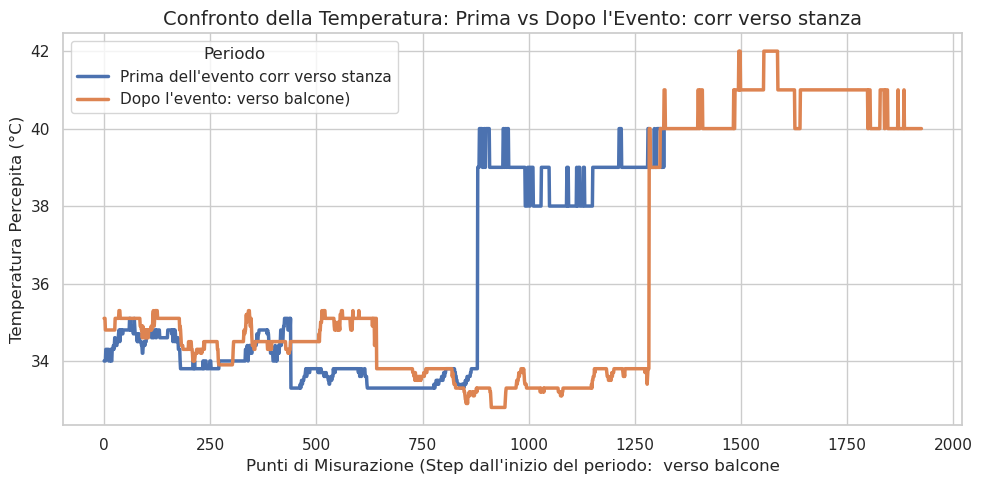

In [11]:
orario_evento = eventoDelimitatore.time 
# reset indici
df_prima = df[df['_time'] < orario_evento].reset_index(drop=True)
df_dopo = df[df['_time'] >= orario_evento].reset_index(drop=True)

# per distinguere i periodi
df_prima['Periodo'] = f'Prima dell\'evento {allEvents[indexEventoPicked-1].description}'
df_dopo['Periodo'] = f'Dopo l\'evento: {allEvents[indexEventoPicked].description})'

df_prima['Step'] = df_prima.index
df_dopo['Step'] = df_dopo.index

df_confronto = pd.concat([df_prima, df_dopo])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df_confronto, 
    x='Step', 
    y='_value', 
    hue='Periodo', 
    linewidth=2.5
)

plt.title(f'Confronto della Temperatura: Prima vs Dopo l\'Evento: {allEvents[indexEventoPicked-1].description}', fontsize=14)
plt.xlabel(f'Punti di Misurazione (Step dall\'inizio del periodo:  {allEvents[indexEventoPicked].description}')
plt.ylabel('Temperatura Percepita (°C)')
plt.tight_layout()

plt.show()